## INFERENCE BEAT

In [ ]:
import torch
from models import MotionTransformer
from utils.get_opt import get_opt
import numpy as np
from os.path import join as pjoin
from trainers import DDPMTrainer

encoder = MotionTransformer(
        input_feats=264,
        num_frames=360,
        num_layers=12,
        latent_dim=768,
        no_clip=False,
        no_eff=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
opt_path = "./checkpoints/beat/beat_baseline/opt.txt"
opt = get_opt(opt_path, device)
opt.do_denoise = True

mean = np.load(pjoin(opt.meta_dir, 'mean.npy'))
std = np.load(pjoin(opt.meta_dir, 'std.npy'))
trainer = DDPMTrainer(opt, encoder)
# trainer.load(pjoin(opt.model_dir, opt.which_epoch + '.tar'))
trainer.load("./checkpoints/beat/beat_baseline/model/ckpt_e065.tar")

if trainer.encoder_ema is not None:
    trainer.encoder_ema.load_state_dict(trainer.encoder.state_dict(), strict=True)

trainer.eval_mode()
trainer.to(opt.device)

result_dict = {}
with torch.no_grad():
        caption = ["Hello everyone, I am so happy!"]
        m_lens = torch.LongTensor([150]).to(device)
        pred_motions = trainer.generate(caption, m_lens, 264)
        motion = pred_motions[0].cpu().numpy()
        print(motion.shape)
opt.result_dir = "./checkpoints/beat/beat_baseline"
np.save(pjoin(opt.result_dir, 'motion_e065.npy'), motion)

/srv/conda/envs/serverai/motiondiff/lib/python3.9/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Reading ./checkpoints/beat/beat_baseline/opt.txt
[INFO] FK/geometric skeleton profile: beat88 (88 joints)


## VISUALIZE MOTION (Position/PyMO flow)

/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/preprocessing.py:151: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Yposition'%joint] = pd.Series(data=[e[1] for e in tree_data[joint][1]], index=pos_df.index)
/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/preprocessing.py:152: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos_df['%s_Zposition'%joint] = pd.Series(data=[e[2] for e in tree_data[joint][1]], index=pos_df.index)
/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/preproces

positions 2 eulers is not supported


/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/viz_tools.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(x=df['%s_Xposition'%joint][frame],
/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/viz_tools.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y=df['%s_Yposition'%joint][frame],
/home/serverai/ltdoanh/Motion_Diffusion/./datasets/pymo/pymo/viz_tools.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

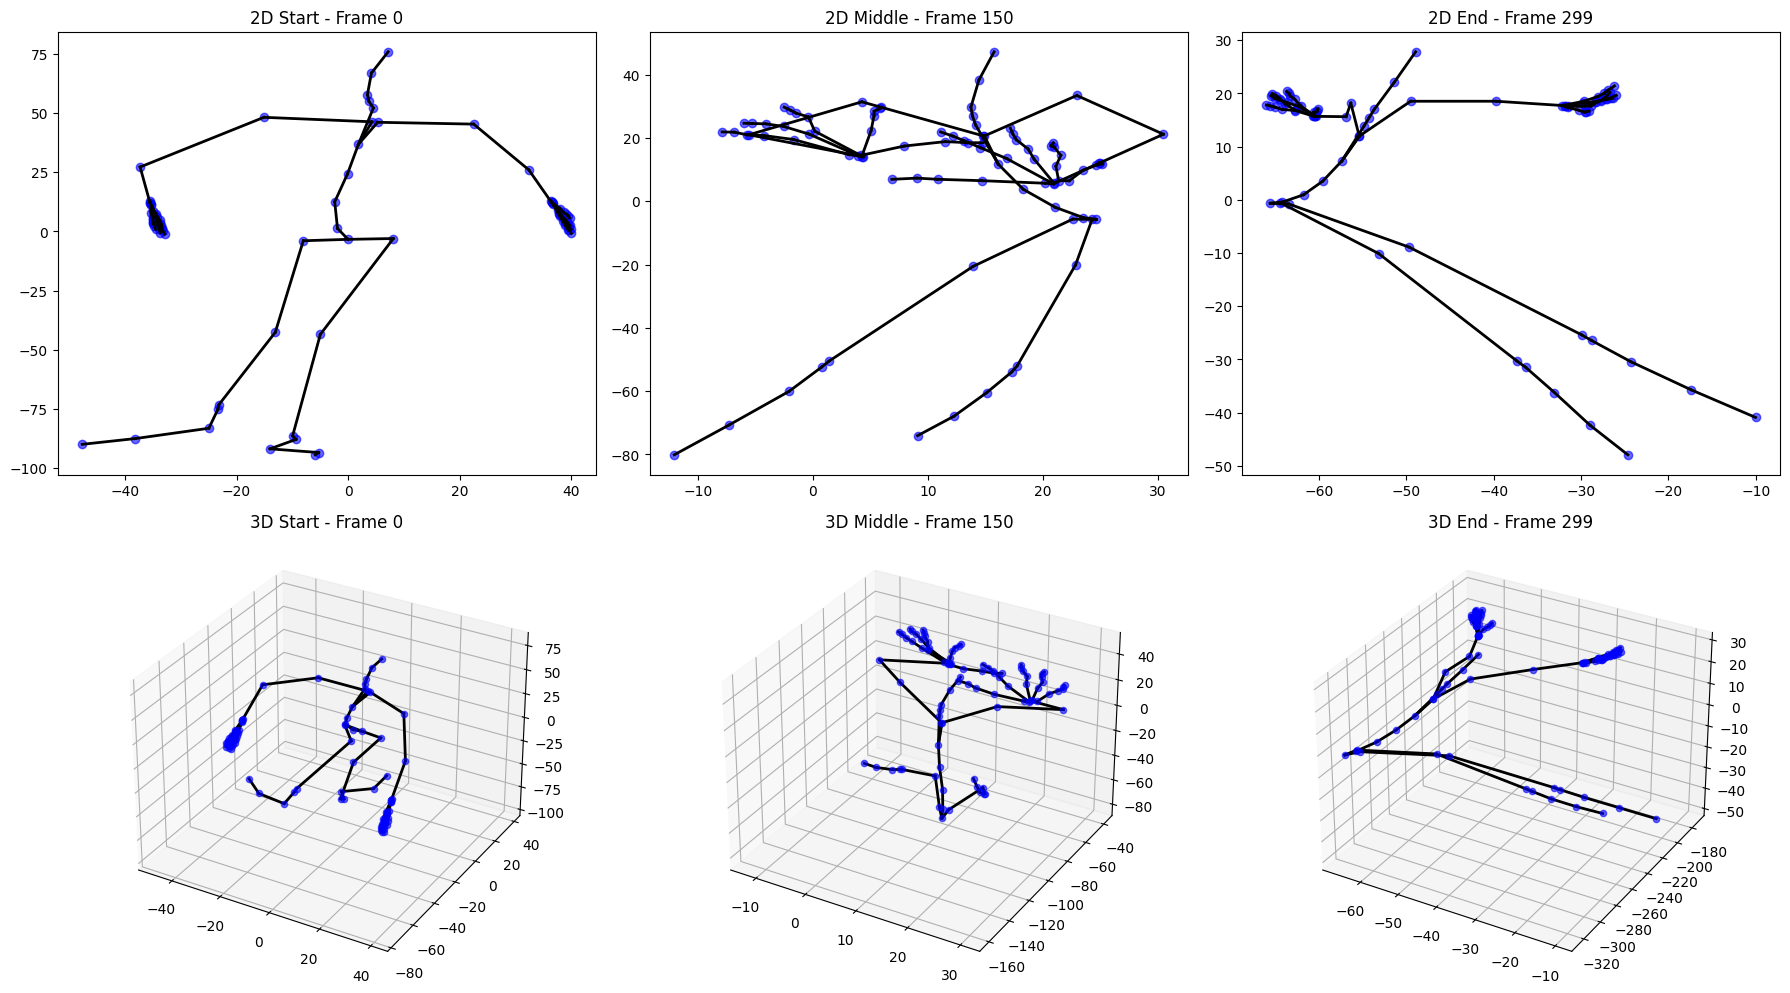

In [ ]:
# ===== VISUALIZE MOTION (Position/PyMO flow) =====
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

PYOM_DIR = "./datasets/pymo"
if PYOM_DIR not in sys.path:
    sys.path.insert(0, PYOM_DIR)

from pymo.parsers import BVHParser
from pymo.preprocessing import *
from pymo.viz_tools import draw_stickfigure, draw_stickfigure3d

def constrain_to_ref_skeleton(generated_mocap, ref_mocap):
    queue = [ref_mocap.root_name]
    gen_df = generated_mocap.values

    while queue:
        parent_name = queue.pop(0)
        children = ref_mocap.skeleton[parent_name]["children"]

        for child_name in children:
            if child_name not in generated_mocap.skeleton:
                continue

            req = [
                f"{parent_name}_Xposition", f"{parent_name}_Yposition", f"{parent_name}_Zposition",
                f"{child_name}_Xposition", f"{child_name}_Yposition", f"{child_name}_Zposition",
            ]
            if not all(c in gen_df.columns for c in req):
                queue.append(child_name)
                continue

            ref_offset = np.array(ref_mocap.skeleton[child_name]["offsets"])
            target_len = np.linalg.norm(ref_offset)
            if target_len < 1e-6:
                queue.append(child_name)
                continue

            p_x, p_y, p_z = gen_df[f"{parent_name}_Xposition"], gen_df[f"{parent_name}_Yposition"], gen_df[f"{parent_name}_Zposition"]
            c_x, c_y, c_z = gen_df[f"{child_name}_Xposition"], gen_df[f"{child_name}_Yposition"], gen_df[f"{child_name}_Zposition"]

            v_x, v_y, v_z = c_x - p_x, c_y - p_y, c_z - p_z
            cur_len = np.sqrt(v_x**2 + v_y**2 + v_z**2)
            cur_len[cur_len == 0] = 1e-6

            s = target_len / cur_len
            gen_df[f"{child_name}_Xposition"] = p_x + v_x * s
            gen_df[f"{child_name}_Yposition"] = p_y + v_y * s
            gen_df[f"{child_name}_Zposition"] = p_z + v_z * s
            queue.append(child_name)

    return generated_mocap

# -------- config --------
# npy_path = "./datasets/BEAT_numpy/npy/1/1_wayne_0_1_1_sentence_000.npy"
npy_path = "./checkpoints/beat/beat_baseline/motion_e065.npy"
fallback_bvh = "./datasets/2_scott_0_55_55.bvh"
frame = 50
use_retarget = True

# -------- build pipeline (position flow) --------
pipeline = Pipeline([
    ("param", MocapParameterizer("position")),
    ("rcpn", RootCentricPositionNormalizer()),
    ("delta", RootTransformer("absolute_translation_deltas")),
    ("const", ConstantsRemover()),
    ("np", Numpyfier()),
    ("down", DownSampler(2)),
    ("stdscale", ListStandardScaler()),
])

# cố tìm đúng BVH gốc của sentence để fit pipeline nhất quán hơn
basename = os.path.basename(npy_path).replace(".npy", "")
source_id = basename.split("_sentence_")[0]
candidate_bvh = f"./datasets/BEAT/beat_english_v0.2.1/beat_english_v0.2.1/{source_id.split('_')[0]}/{source_id}.bvh"
bvh_fit_path = candidate_bvh if os.path.exists(candidate_bvh) else fallback_bvh

if not os.path.exists(bvh_fit_path):
    raise FileNotFoundError(f"Không tìm thấy BVH để fit pipeline: {bvh_fit_path}")

parser = BVHParser()
ref_mocap = parser.parse(bvh_fit_path)
pipeline.fit([ref_mocap])

# -------- load feature (position-flow npy) --------
if not os.path.exists(npy_path):
    raise FileNotFoundError(f"Không tìm thấy file motion: {npy_path}")

motion_feat = np.load(npy_path)
if motion_feat.ndim == 3 and motion_feat.shape[0] == 1:
    motion_feat = motion_feat[0]
if motion_feat.ndim != 2:
    raise ValueError(f"Expected 2D motion feature, got {motion_feat.shape}")

# QUAN TRỌNG: position-flow npy -> không nhân std/mean ở đây
reconstructed = pipeline.inverse_transform([motion_feat])[0]

if use_retarget:
    reconstructed = constrain_to_ref_skeleton(reconstructed, ref_mocap)

# -------- draw --------
# frame = min(frame, len(reconstructed.values) - 1)

# fig1 = plt.figure(figsize=(10, 8))
# draw_stickfigure(reconstructed, frame=frame)
# plt.title(f"2D Stick Figure (Position/PyMO) - Frame {frame}")
# plt.tight_layout()
# plt.show()

# fig2 = plt.figure(figsize=(10, 8))
# draw_stickfigure3d(reconstructed, frame=frame)
# plt.title(f"3D Stick Figure (Position/PyMO) - Frame {frame}")
# plt.tight_layout()
# plt.show()

# -------- draw: start / middle / end --------
n_frames = len(reconstructed.values)
frame_ids = [0, n_frames // 2, n_frames - 1]
frame_names = ["Start", "Middle", "End"]

fig = plt.figure(figsize=(18, 10))

for i, (fid, name) in enumerate(zip(frame_ids, frame_names)):
    # 2D row
    ax2d = fig.add_subplot(2, 3, i + 1)
    draw_stickfigure(reconstructed, frame=fid, ax=ax2d)
    ax2d.set_title(f"2D {name} - Frame {fid}")

    # 3D row
    ax3d = fig.add_subplot(2, 3, i + 4, projection="3d")
    draw_stickfigure3d(reconstructed, frame=fid, ax=ax3d)
    ax3d.set_title(f"3D {name} - Frame {fid}")

plt.tight_layout()
plt.show()